# Previsão de AVC com Random Forest e XGBoost usando SMOTE


Este notebook realiza uma análise comparativa entre dois dos melhores modelos para dados tabulares aplicando SMOTE para balancear o dataset.:

- **Random Forest Classifier**
- **XGBoost Classifier**

O objetivo é prever se um paciente terá um AVC com base em características demográficas e clínicas.


In [1]:
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (2).csv


In [2]:
!pip install imblearn

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Carregando o dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.drop(columns=["id"], inplace=True)
df["bmi"] = SimpleImputer(strategy="mean").fit_transform(df[["bmi"]])

# Codificação de variáveis categóricas
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform)

# Separação de variáveis
X = df.drop(columns=["stroke"])
y = df["stroke"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Escalonamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
from imblearn.over_sampling import SMOTE

# Aplicando SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)
rf_preds = rf_model.predict(X_test_scaled)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=100, random_state=42)
xgb_model.fit(X_resampled, y_resampled)
xgb_preds = xgb_model.predict(X_test_scaled)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:19:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Random Forest com SMOTE")
print(classification_report(y_test, rf_preds))

print("XGBoost com SMOTE")
print(classification_report(y_test, xgb_preds))

Random Forest com SMOTE
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.16      0.14      0.15        50

    accuracy                           0.92      1022
   macro avg       0.56      0.55      0.56      1022
weighted avg       0.92      0.92      0.92      1022

XGBoost com SMOTE
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.19      0.14      0.16        50

    accuracy                           0.93      1022
   macro avg       0.57      0.55      0.56      1022
weighted avg       0.92      0.93      0.92      1022



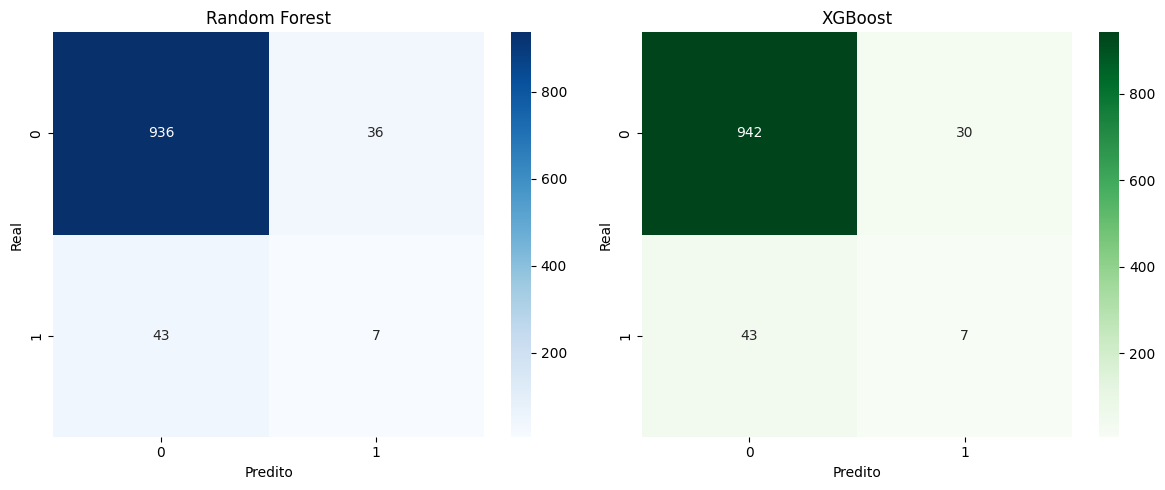

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt="d", cmap="Blues", ax=axs[0])
axs[0].set_title("Random Forest")
axs[0].set_xlabel("Predito")
axs[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt="d", cmap="Greens", ax=axs[1])
axs[1].set_title("XGBoost")
axs[1].set_xlabel("Predito")
axs[1].set_ylabel("Real")
plt.tight_layout()
plt.show()

# 🔍 Análise Não Supervisionada com K-Means

Vamos explorar agrupamentos naturais nos dados usando K-Means, sem utilizar a variável alvo `stroke`. Isso pode revelar padrões ocultos nos dados que se correlacionam com a ocorrência de AVC.

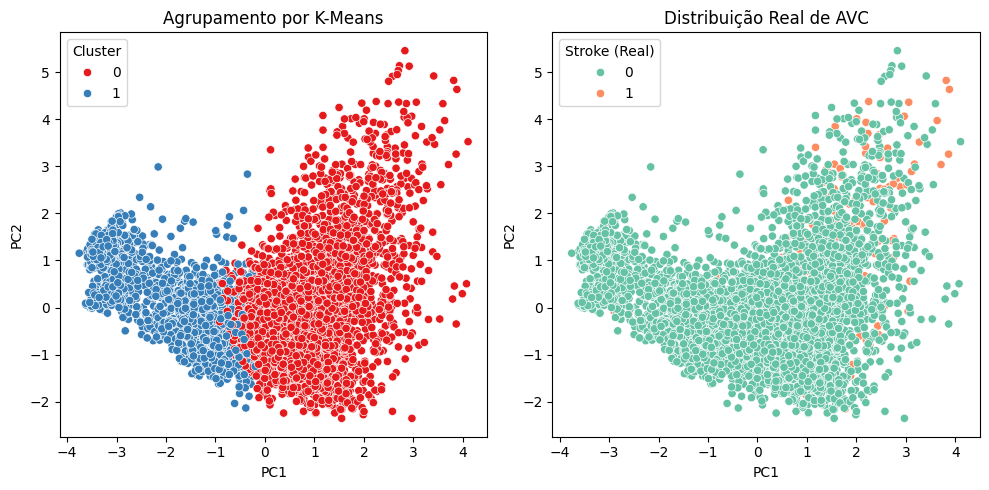

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Remover colunas 'stroke' e 'id' apenas se existirem no DataFrame
cols_to_drop = [col for col in ['stroke', 'id'] if col in df.columns]
X_unsup = df.drop(columns=cols_to_drop)

# Se houver colunas categóricas, aplicar get_dummies
X_unsup = pd.get_dummies(X_unsup)

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

# Aplicar KMeans com 2 clusters (hipótese: AVC vs Não-AVC)
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Reduzir dimensionalidade para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Criar DataFrame para visualização
df_vis = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_vis['Cluster'] = clusters
df_vis['Stroke (Real)'] = df['stroke'].values

# Visualizar agrupamentos
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title('Agrupamento por K-Means')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Stroke (Real)', palette='Set2')
plt.title('Distribuição Real de AVC')
plt.tight_layout()
plt.show()

## 📊 Avaliação dos Clusters - KMeans

### 🔹 Gráfico de Silhueta

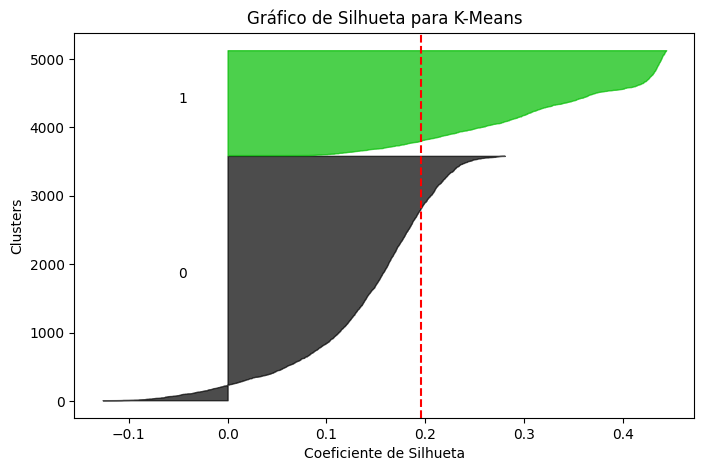

In [9]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np

silhouette_avg = silhouette_score(X_scaled, clusters)
sample_silhouette_values = silhouette_samples(X_scaled, clusters)

plt.figure(figsize=(8, 5))
y_lower = 10
for i in range(2):
    ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / 2)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.title("Gráfico de Silhueta para K-Means")
plt.xlabel("Coeficiente de Silhueta")
plt.ylabel("Clusters")
plt.show()

### 🔹 Método do Cotovelo

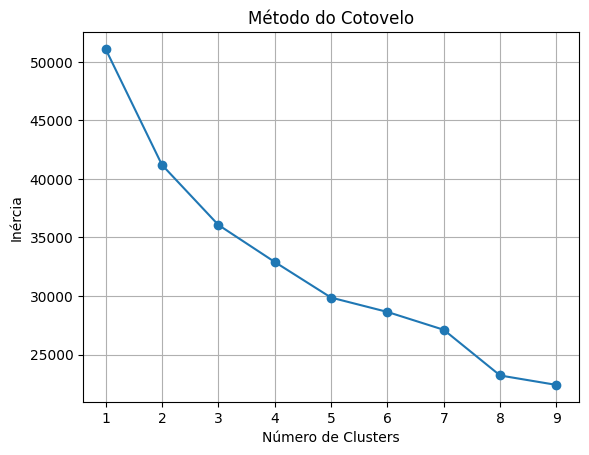

In [10]:
inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1, 10), inertias, marker='o')
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inércia")
plt.grid(True)
plt.show()

### 🔹 Heatmap das Médias por Cluster

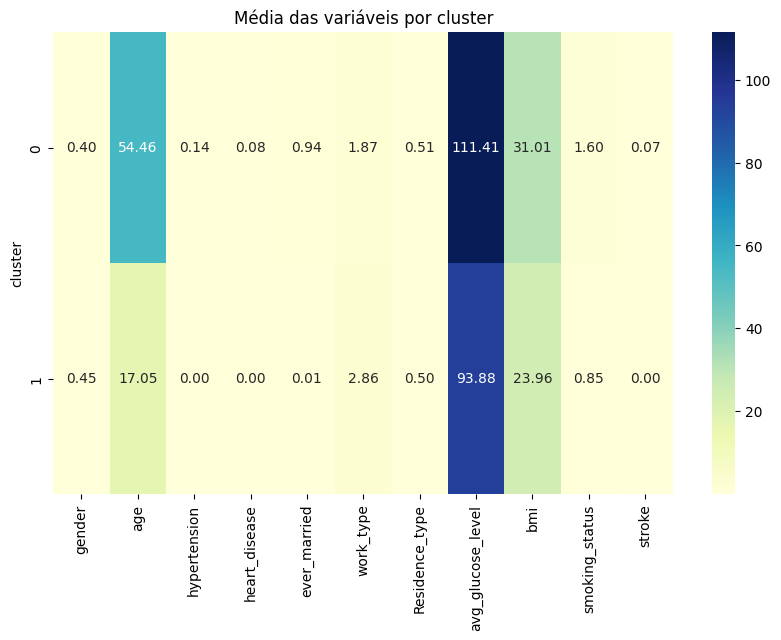

In [11]:
df_clustered = df.copy()
df_clustered['cluster'] = clusters
cluster_means = df_clustered.groupby('cluster').mean(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, annot=True, fmt='.2f', cmap="YlGnBu")
plt.title("Média das variáveis por cluster")
plt.show()